<p align="center"><a href="https://www.plus2net.com/python/pandas-dataframe-plot-bar.php"><img src="https://www.plus2net.com/images/top2.jpg" alt="plus2net Python Tutorials" width="300"></a></p>

# Pandas Bar Charts: Compare Categories and Sales

**Pandas Tutorial Series — Plotting**

[Read the tutorial](https://www.plus2net.com/python/pandas-dataframe-plot-bar.php)

Run cells from top to bottom. Save a copy in Drive before experimenting. Pandas and Matplotlib are available in Colab. The student and sales datasets are synthetic and embedded; no database or external download is needed. Reset helpers provide fresh data for each example. Try the exercise before its solution. The export cell writes a PNG in the runtime: download it from Colab's Files sidebar to keep it.

## Create Your First Bar Chart

A bar chart compares values across categories. Here each student name is a category and MARK is the numeric value. Select <code>x="NAME"</code> and <code>y="MARK"</code> explicitly so an unrelated numeric ID column would not become another plotted series. Pandas returns a Matplotlib Axes that you can use to adjust labels or save the figure.

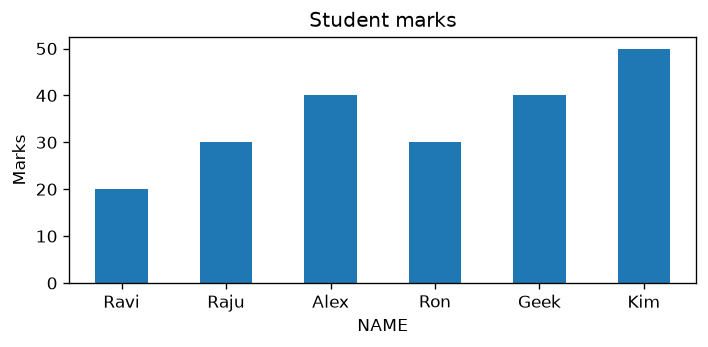

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def student_data():
    return pd.DataFrame({
        "NAME": ["Ravi", "Raju", "Alex", "Ron", "Geek", "Kim"],
        "MARK": [20, 30, 40, 30, 40, 50],
        "ENGLISH": [30, 20, 30, 40, 20, 40]
    })

df = student_data()
ax = df.plot.bar(x="NAME", y="MARK", title="Student marks",
                 figsize=(6, 3), rot=0, legend=False)
ax.set_ylabel("Marks")
plt.tight_layout()
plt.show()

**What to check:** Six bars: Ravi 20, Raju 30, Alex 40, Ron 30, Geek 40 and Kim 50.

## Titles, Figure Size and x/y Selection

Use <code>title</code> for a meaningful heading and <code>figsize=(width, height)</code> for dimensions in inches. <code>x</code> supplies category labels; <code>y</code> selects numeric columns. Make the figure wider when labels would otherwise overlap. The <a href="https://www.plus2net.com/python/pandas-dataframe.php">DataFrame tutorial</a> explains the table structure; Python <a href="https://www.plus2net.com/python/tuple.php">tuples</a> supply the size pair.

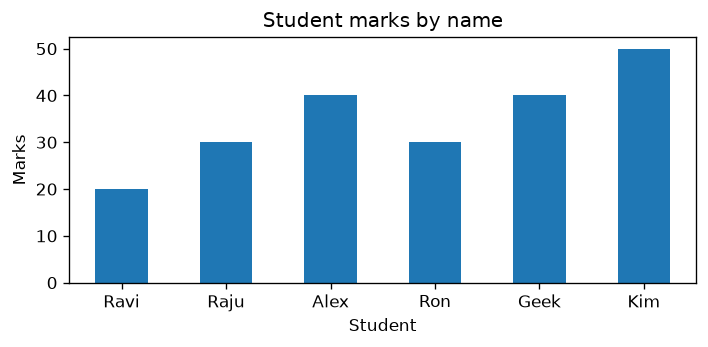

In [ ]:
df = student_data()
ax = df.plot.bar(x="NAME", y="MARK", title="Student marks by name",
                 figsize=(6, 3), rot=0, legend=False)
ax.set_xlabel("Student")
ax.set_ylabel("Marks")
plt.tight_layout()
plt.show()

## use_index: Choose Index Labels or Positions

Without <code>x</code>, the index supplies category labels. Set the names as the index to compare <code>use_index=True</code> and <code>use_index=False</code>. The second chart labels positions 0 through 5. If you want a particular column as the labels, use <code>x</code> explicitly.

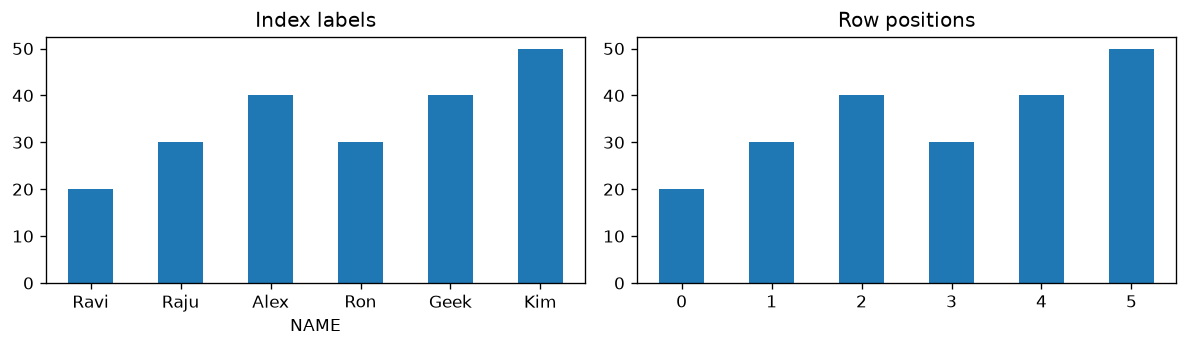

In [ ]:
df = student_data().set_index("NAME")
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
df.plot.bar(y="MARK", use_index=True, ax=axes[0],
            title="Index labels", rot=0, legend=False)
df.plot.bar(y="MARK", use_index=False, ax=axes[1],
            title="Row positions", rot=0, legend=False)
plt.tight_layout()
plt.show()

## Add a Useful Grid

A light horizontal grid helps readers estimate values. Keep the bars in front of the grid. <code>grid=True</code> enables a grid through the plotting options; the Axes methods give more control over direction and appearance.

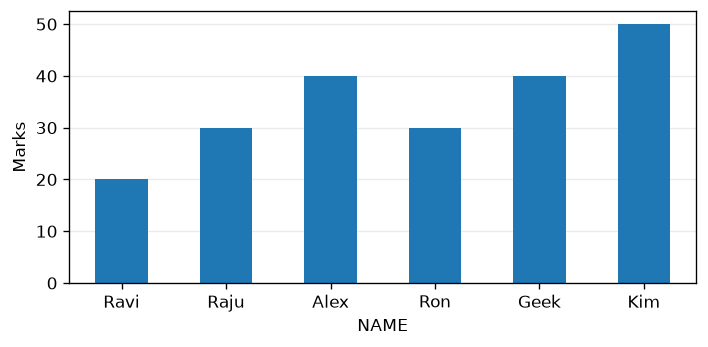

In [ ]:
df = student_data()
ax = df.plot.bar(x="NAME", y="MARK", grid=False,
                 legend=False, rot=0, figsize=(6, 3))
ax.yaxis.grid(True, alpha=0.25)
ax.set_axisbelow(True)
ax.set_ylabel("Marks")
plt.tight_layout()
plt.show()

## Show a Legend When It Explains the Series

One series already named on the axis may not need a legend. Multiple series need clear labels so readers can identify them. <code>legend=False</code> hides the legend; <code>legend=True</code> shows it.

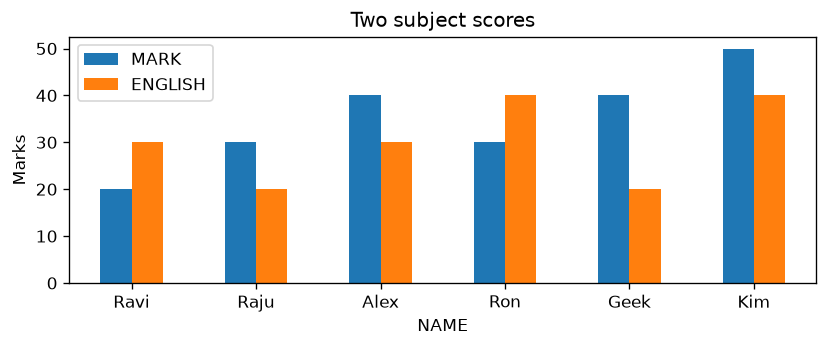

In [ ]:
df = student_data()
ax = df.plot.bar(x="NAME", y=["MARK", "ENGLISH"], legend=True,
                 rot=0, figsize=(7, 3), title="Two subject scores")
ax.set_ylabel("Marks")
plt.tight_layout()
plt.show()

## Set One Colour Using RGB or a Named Colour

An RGB tuple contains red, green and blue components between 0 and 1. A named colour or hexadecimal string also works. This one-item list assigns the same colour to the MARK series. Use colours consistently across related charts.

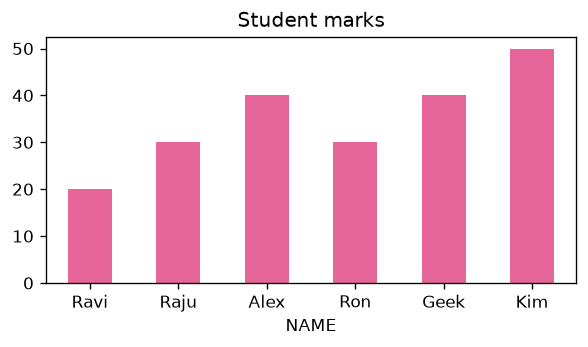

In [ ]:
df = student_data()
my_colors = [(0.9, 0.4, 0.6)]
ax = df.plot.bar(x="NAME", y="MARK", color=my_colors,
                 figsize=(5, 3), legend=False, rot=0,
                 title="Student marks")
plt.tight_layout()
plt.show()

## Assign Different Colours to Different Series

For <code>DataFrame.plot.bar()</code>, a colour list maps to the plotted columns. With only one numeric series, only the first list colour is used. Plot two subjects to use both RGB colours. A dictionary keyed by column name can make that mapping explicit.

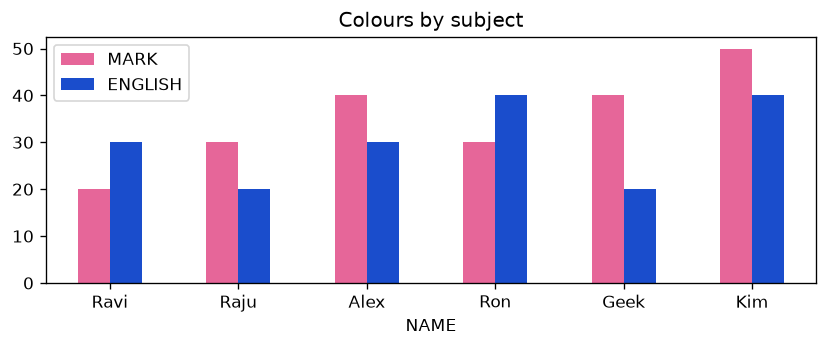

In [ ]:
df = student_data()
my_colors = [(0.9, 0.4, 0.6), (0.1, 0.3, 0.8)]
ax = df.plot.bar(x="NAME", y=["MARK", "ENGLISH"], color=my_colors,
                 rot=0, figsize=(7, 3), title="Colours by subject")
plt.tight_layout()
plt.show()

## Colour Individual Bars in One Series

Use a Series bar plot when you want a colour for each category. The colour list below has one RGB tuple per student. Different colours can highlight categories, but a single colour is often clearer when colour does not encode additional information.

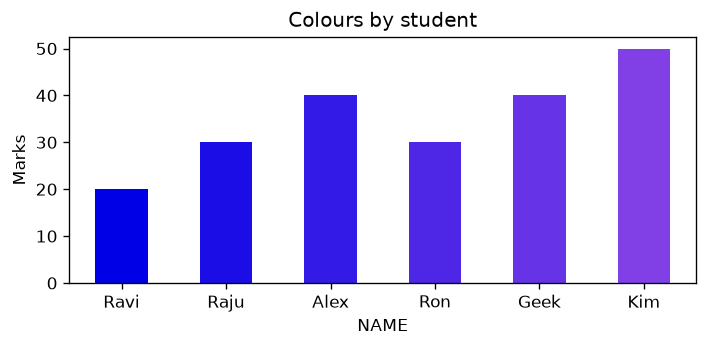

In [ ]:
df = student_data()
my_colors = [(position / 10.0, position / 20.0, 0.9)
             for position in range(len(df))]
ax = df.set_index("NAME")["MARK"].plot.bar(
    color=my_colors, rot=0, figsize=(6, 3), title="Colours by student")
ax.set_ylabel("Marks")
plt.tight_layout()
plt.show()

## Rotate Labels or Use a Horizontal Chart

<code>rot</code> controls tick-label rotation. Try 45 degrees for longer names; 180 degrees makes labels upside down and is rarely readable. Keep 0 degrees for short labels. If names are long, <a href="https://www.plus2net.com/python/pandas-dataframe-plot-barh.php">horizontal bars</a> often work better.

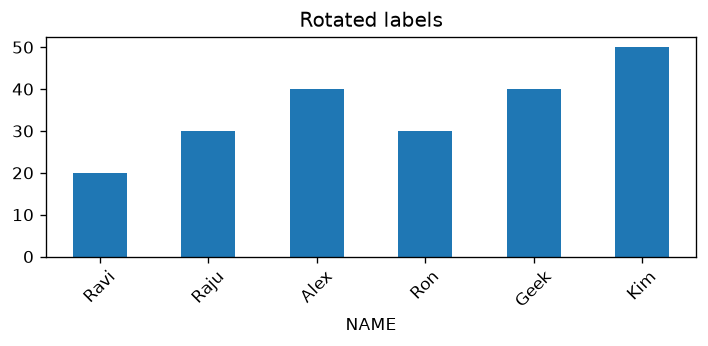

In [ ]:
df = student_data()
ax = df.plot.bar(x="NAME", y="MARK", rot=45,
                 figsize=(6, 3), legend=False, title="Rotated labels")
plt.tight_layout()
plt.show()

## Compare Subjects with Grouped Bars

Grouped bars place series side by side within each category. This makes MARK and ENGLISH easier to compare for each student. Both measurements use the same units, so one y-axis works. Choose the numeric columns explicitly.

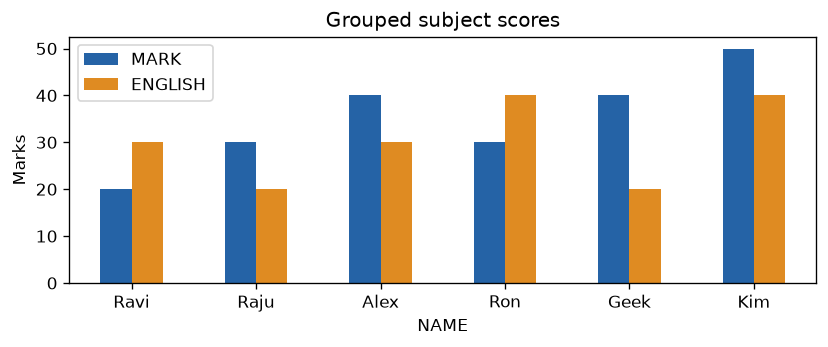

In [ ]:
df = student_data()
ax = df.plot.bar(x="NAME", y=["MARK", "ENGLISH"], stacked=False,
                 color={"MARK": "#2563a6", "ENGLISH": "#df8b22"},
                 rot=0, figsize=(7, 3), title="Grouped subject scores")
ax.set_ylabel("Marks")
plt.tight_layout()
plt.show()

## Use Stacked Bars for Parts of a Meaningful Total

<code>stacked=True</code> places series on top of each other. It emphasises totals and composition, while making individual segments harder to compare. Stack values only when adding them answers a meaningful question. Here the total is the combined score across two subjects.

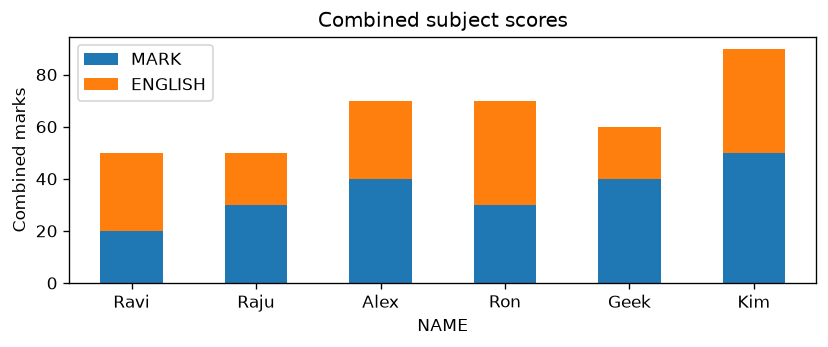

In [ ]:
df = student_data()
ax = df.plot.bar(x="NAME", y=["MARK", "ENGLISH"], stacked=True,
                 figsize=(7, 3), rot=0, title="Combined subject scores")
ax.set_ylabel("Combined marks")
plt.tight_layout()
plt.show()

**What to check:** Kim has a combined score of 90; Geek has 60.

## Separate Series into Subplots

<code>subplots=True</code> creates a separate chart for each numeric series. A list of titles supplies one title per subplot. This is useful when a shared chart would be crowded. Shared y-axis limits help readers compare subjects with the same units.

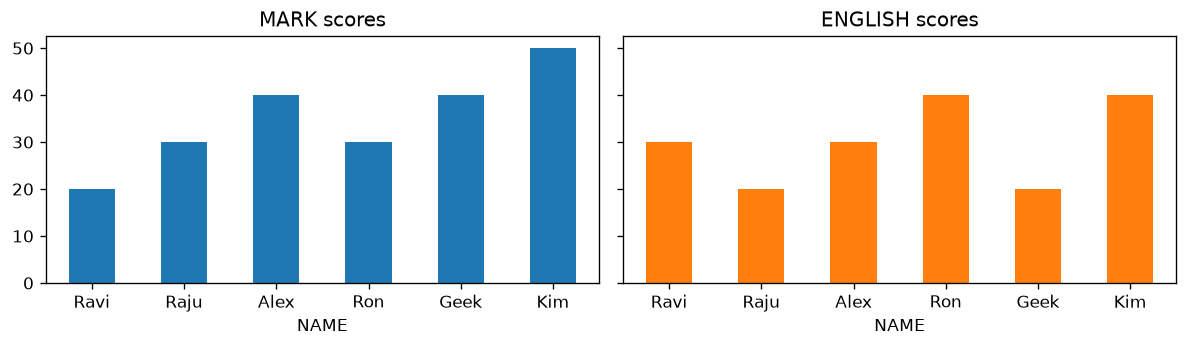

In [ ]:
df = student_data()
axes = df.plot.bar(x="NAME", y=["MARK", "ENGLISH"], subplots=True,
                   title=["MARK scores", "ENGLISH scores"],
                   layout=(1, 2), sharey=True, rot=0, legend=False,
                   figsize=(10, 3))
plt.tight_layout()
plt.show()

## Logarithmic Scales: Use Only for a Clear Reason

<code>logy=True</code> makes the numeric axis logarithmic. This can show multiplicative differences when positive values span orders of magnitude. Zero and negative values do not work on a standard log scale. Because bar lengths normally imply a zero baseline, a log-scale line or point chart is often easier to interpret. <code>logx</code> and <code>loglog</code> are plotting options, but they are generally unsuitable for a categorical bar axis.

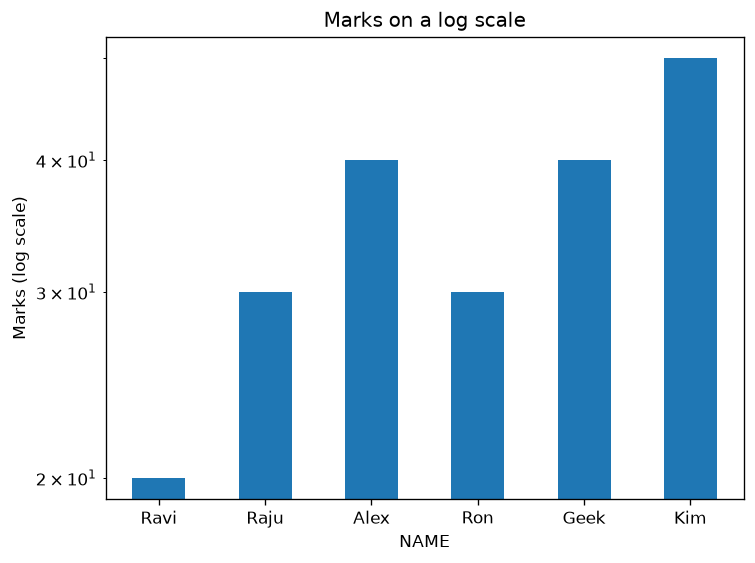

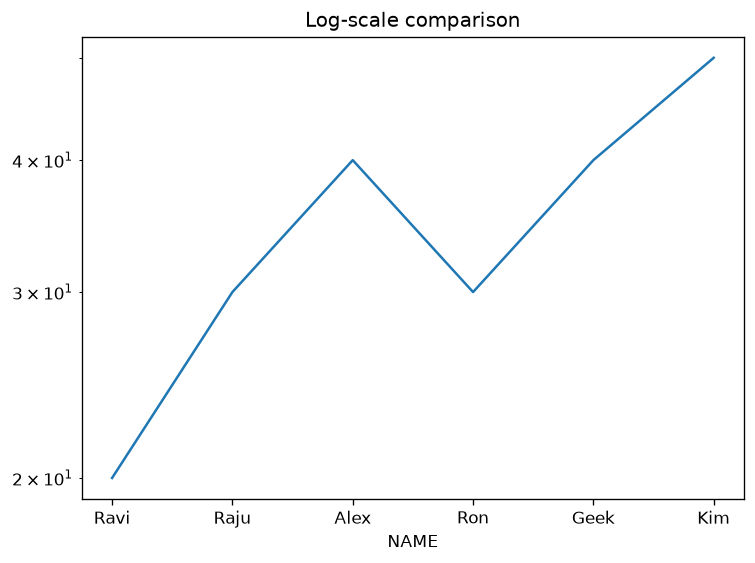

In [ ]:
df = student_data()
ax = df.plot.bar(x="NAME", y="MARK", logy=True,
                 rot=0, legend=False, title="Marks on a log scale")
ax.set_ylabel("Marks (log scale)")
plt.tight_layout()
plt.show()

# A line plot is another way to demonstrate the numeric log scale.
ax = df.plot.line(x="NAME", y="MARK", logy=True,
                  legend=False, title="Log-scale comparison")
plt.tight_layout()
plt.show()

## secondary_y: Plot a Series on the Right Axis

A secondary axis uses a different scale. Moving all series to it with <code>secondary_y=True</code> is possible, but placing one identified series on the right is usually more useful. Dual axes can make unrelated changes appear comparable; separate charts are often clearer. Always label both units.

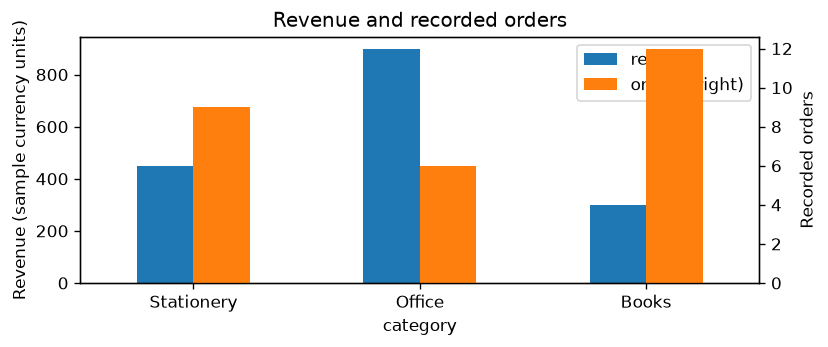

In [ ]:
df = pd.DataFrame({"category": ["Stationery", "Office", "Books"],
                   "revenue": [450, 900, 300], "orders": [9, 6, 12]})
ax = df.plot.bar(x="category", y=["revenue", "orders"],
                 secondary_y="orders", rot=0, figsize=(7, 3),
                 title="Revenue and recorded orders")
ax.set_ylabel("Revenue (sample currency units)")
ax.right_ax.set_ylabel("Recorded orders")
plt.tight_layout()
plt.show()

## mark_right: Identify the Secondary-Axis Series

By default the legend adds <code>(right)</code> to a secondary-axis series. <code>mark_right=False</code> removes that suffix, so make the axis association clear another way. The first example below moves MARK to the right axis; the second hides the suffix and names the axis explicitly.

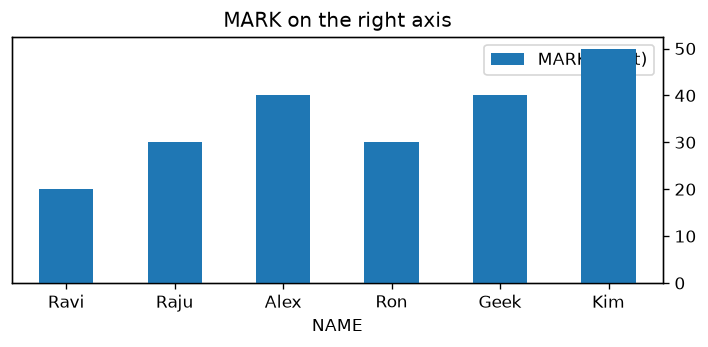

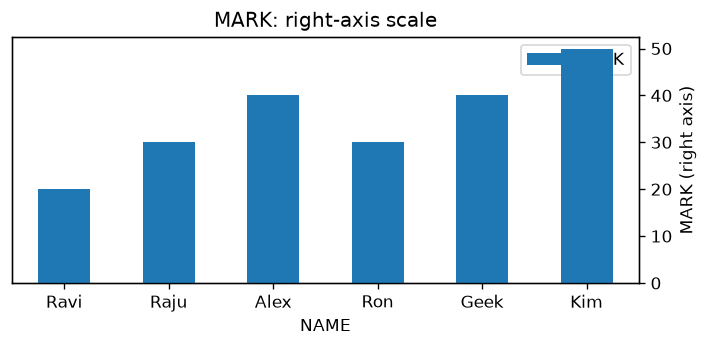

In [ ]:
df = student_data()
ax = df.plot.bar(x="NAME", y="MARK", secondary_y=True,
                 mark_right=True, rot=0, figsize=(6, 3),
                 title="MARK on the right axis")
plt.tight_layout()
plt.show()

ax = df.plot.bar(x="NAME", y="MARK", secondary_y=True,
                 mark_right=False, rot=0, figsize=(6, 3),
                 title="MARK: right-axis scale")
ax.set_ylabel("MARK (right axis)")
plt.tight_layout()
plt.show()

## Practical Sales Data: Aggregate Before Plotting

Repeated categories need a summary before plotting: Pandas draws bars for rows, not automatically for unique categories. This synthetic dataset contains recorded revenue by product category and channel. All combinations are observed; the revenue values are non-negative and have the same units.

In [ ]:
def sales_data():
    return pd.DataFrame({
        "category": ["Stationery", "Office", "Books", "Stationery", "Office", "Books"],
        "channel": ["Online", "Online", "Online", "Store", "Store", "Store"],
        "revenue": [120, 300, 180, 80, 250, 220]
    })

sales = sales_data()
totals = sales.groupby("category")["revenue"].sum().sort_values(ascending=False)
print(totals)
assert totals.sum() == sales["revenue"].sum()
assert totals.to_dict() == {"Office": 550, "Books": 400, "Stationery": 200}

**Expected output**

```text
category
Office        550
Books         400
Stationery    200
Name: revenue, dtype: int64
```

## Plot Sorted Category Totals with Value Labels

Use <a href="https://www.plus2net.com/python/pandas-dataframe-groupby.php">groupby()</a> to calculate category totals before drawing the chart. Sorting makes the ranking easier to read. Value labels show the exact totals; keep a zero baseline for this non-negative bar chart so bar lengths remain comparable.

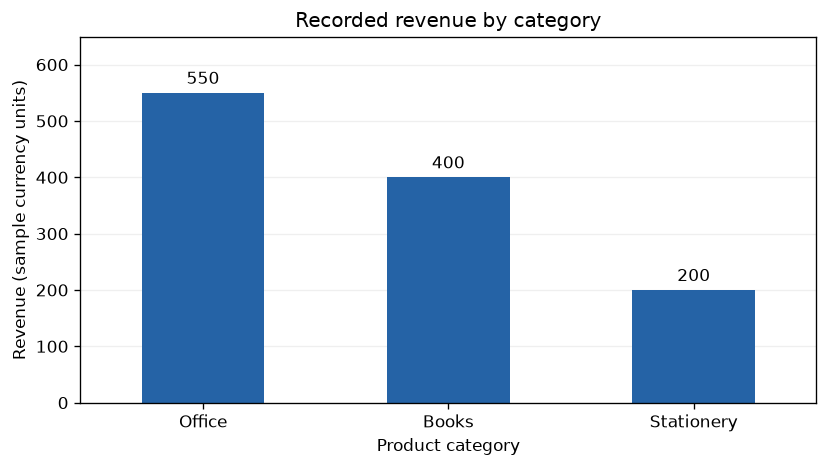

In [ ]:
sales = sales_data()
totals = sales.groupby("category")["revenue"].sum().sort_values(ascending=False)
ax = totals.plot.bar(color="#2563a6", rot=0, figsize=(7, 4),
                      title="Recorded revenue by category")
ax.set_xlabel("Product category")
ax.set_ylabel("Revenue (sample currency units)")
ax.set_ylim(0, totals.max() * 1.18)
ax.bar_label(ax.containers[0], fmt="%.0f", padding=3)
ax.yaxis.grid(True, alpha=0.2)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

**What to check:** Office 550, Books 400 and Stationery 200; total recorded revenue is 1,150.

## Compare Sales Channels with Grouped Bars

Build a category-by-channel table with <a href="https://www.plus2net.com/python/pandas-pivot-table.php">pivot_table()</a>. Each channel becomes a numeric series. Use a stable colour for each channel. If a real dataset has absent combinations, decide whether they mean zero sales or missing records before filling them.

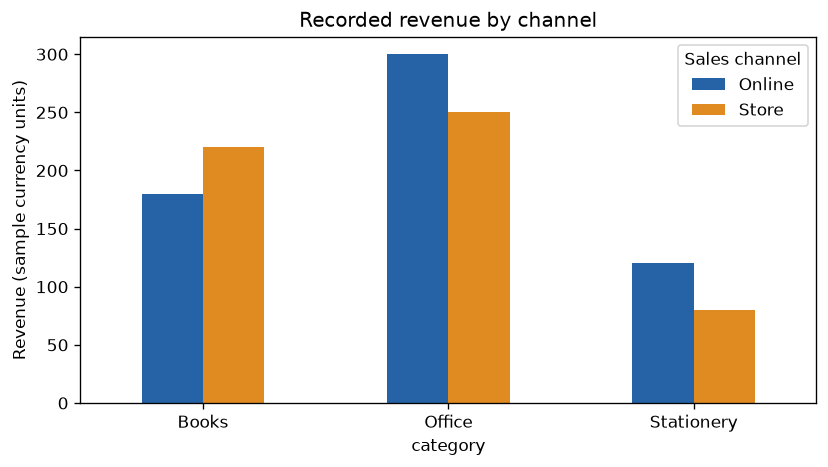

In [ ]:
sales = sales_data()
report = sales.pivot_table(index="category", columns="channel",
                           values="revenue", aggfunc="sum")
print(report)
ax = report.plot.bar(stacked=False, rot=0, figsize=(7, 4),
                      color={"Online": "#2563a6", "Store": "#df8b22"},
                      title="Recorded revenue by channel")
ax.set_ylabel("Revenue (sample currency units)")
ax.legend(title="Sales channel")
plt.tight_layout()
plt.show()

**Expected output**

```text
channel     Online  Store
category                 
Books          180    220
Office         300    250
Stationery     120     80
```

**What to check:** For Books, Store revenue is 220 and Online revenue is 180.

## Show Channel Contributions with Stacked Bars

Stacking makes category totals visible while retaining channel contributions. These series represent parts of the same recorded revenue total, so adding them is meaningful. Use grouped bars instead when comparing Online values with Store values is the main task.

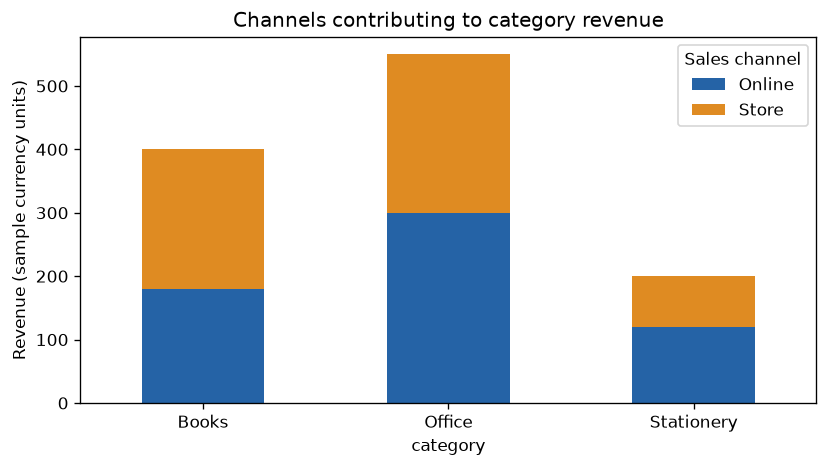

In [ ]:
sales = sales_data()
report = sales.pivot_table(index="category", columns="channel",
                           values="revenue", aggfunc="sum")
ax = report.plot.bar(stacked=True, rot=0, figsize=(7, 4),
                      color={"Online": "#2563a6", "Store": "#df8b22"},
                      title="Channels contributing to category revenue")
ax.set_ylabel("Revenue (sample currency units)")
ax.legend(title="Sales channel")
plt.tight_layout()
plt.show()
assert report.sum().sum() == sales["revenue"].sum()

**What to check:** Stack heights are Books 400, Office 550 and Stationery 200.

## Compare Composition with 100% Stacked Bars

Divide each category row by its total and multiply by 100. This compares channel shares rather than revenue amounts. A category with no positive total needs separate handling. A 100% chart hides total size, so present the category-total chart alongside it when amounts matter.

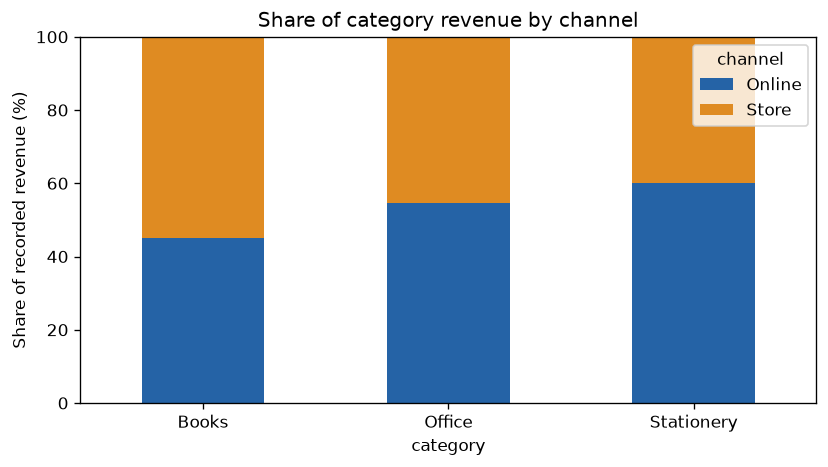

In [ ]:
sales = sales_data()
report = sales.pivot_table(index="category", columns="channel",
                           values="revenue", aggfunc="sum")
totals = report.sum(axis=1)
assert totals.gt(0).all()
percentages = report.div(totals, axis=0).mul(100)
print(percentages.round(1))
ax = percentages.plot.bar(stacked=True, rot=0, figsize=(7, 4),
                           color={"Online": "#2563a6", "Store": "#df8b22"},
                           title="Share of category revenue by channel")
ax.set_ylim(0, 100)
ax.set_ylabel("Share of recorded revenue (%)")
plt.tight_layout()
plt.show()
assert percentages.sum(axis=1).round(6).eq(100).all()

**Expected output**

```text
channel     Online  Store
category                 
Books         45.0   55.0
Office        54.5   45.5
Stationery    60.0   40.0
```

**What to check:** Stationery is 60% Online and 40% Store; every bar totals 100%.

## Save the Chart as a PNG Image

Save through the returned Axes figure, before closing it. <code>dpi</code> controls raster resolution and <code>bbox_inches="tight"</code> helps include labels. In Colab the file is created in the runtime, not automatically in your Drive: download it from the Files sidebar. See the <a href="https://www.plus2net.com/python/colab.php">Colab guide</a> for working with notebook files.

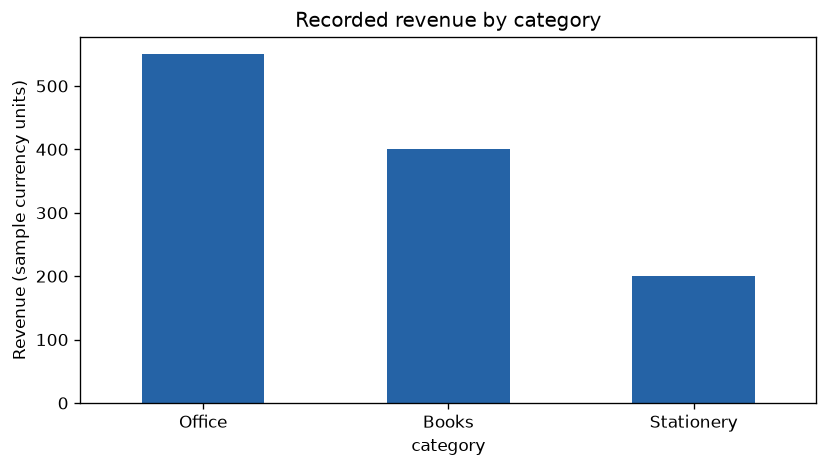

In [ ]:
sales = sales_data()
totals = sales.groupby("category")["revenue"].sum().sort_values(ascending=False)
ax = totals.plot.bar(rot=0, color="#2563a6", figsize=(7, 4),
                      title="Recorded revenue by category")
ax.set_ylabel("Revenue (sample currency units)")
plt.tight_layout()
ax.figure.savefig("pandas_category_sales.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved pandas_category_sales.png")

**Expected output**

```text
Saved pandas_category_sales.png
```

## Choose a Chart That Answers the Question

Use vertical bars for a small number of categories and <a href="https://www.plus2net.com/python/pandas-dataframe-plot-barh.php">horizontal bars</a> for long names. Use <a href="https://www.plus2net.com/python/pandas-dataframe-plot-line.php">line plots</a> for an ordered trend, <a href="https://www.plus2net.com/python/pandas-dataframe-plot-hist.php">histograms</a> for a numeric distribution and <a href="https://www.plus2net.com/python/pandas-dataframe-plot-scatter.php">scatter plots</a> for relationships between two numeric variables. Grouped bars compare series; stacked bars explain a meaningful total; 100% stacked bars compare proportions. Do not mix different units in one stack.

## Common Bar-Chart Problems

<strong>No numeric data to plot:</strong> check the selected column dtype and validate text-to-number conversion before plotting. <strong>Repeated category labels:</strong> aggregate first; use <a href="https://www.plus2net.com/python/pandas-dataframe-value_counts.php">value_counts()</a> when you need counts. <strong>Only one list colour appears:</strong> DataFrame colour lists map to series; use the Series example for individual bars. <strong>Labels overlap:</strong> increase figure width, rotate labels or choose horizontal bars. <strong>Blank saved image:</strong> save the Axes figure before closing it. <strong>Missing observations:</strong> investigate them before applying <a href="https://www.plus2net.com/python/pandas-dataframe-fillna.php">fillna()</a>; unknown values are not automatically zero. <strong>Misleading comparisons:</strong> use clear units, a suitable baseline and consistent category order.

## Exercise: Chart Total Revenue by Channel

Calculate total recorded revenue for Online and Store, draw a bar chart and label both values. Predict the totals before running the solution. Verify that the two bars add up to the original revenue sum. Expected totals: Online 600 and Store 550.

## Exercise Solution

Group by channel, sum the recorded revenue and display the exact values above the bars. The assertion verifies that the aggregation did not lose any of the six source records.

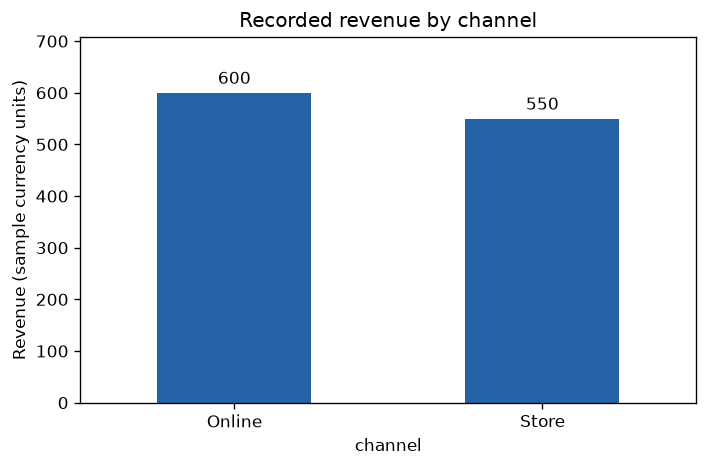

In [ ]:
sales = sales_data()
totals = sales.groupby("channel")["revenue"].sum()
print(totals)
assert totals.to_dict() == {"Online": 600, "Store": 550}
assert totals.sum() == sales["revenue"].sum()
ax = totals.plot.bar(rot=0, color="#2563a6", figsize=(6, 4),
                      title="Recorded revenue by channel")
ax.set_ylabel("Revenue (sample currency units)")
ax.set_ylim(0, totals.max() * 1.18)
ax.bar_label(ax.containers[0], fmt="%.0f", padding=3)
plt.tight_layout()
plt.show()

**Expected output**

```text
channel
Online    600
Store     550
Name: revenue, dtype: int64
```

## Practice in Google Colab

<a class="btn btn-outline-primary" href="https://colab.research.google.com/github/plus2net/pandas/blob/main/pandas_bar_chart_practice.ipynb" target="_blank" rel="noopener">Open in Google Colab</a> <a class="btn btn-outline-secondary" href="https://github.com/plus2net/pandas/blob/main/pandas_bar_chart_practice.ipynb" target="_blank" rel="noopener">View on GitHub</a><br>Run the examples, change category values and practise choosing grouped or stacked bars. Both sample datasets are included in the notebook. Save a copy in Drive to keep your changes.